### Retrieval and generation

### Retrieval

#### 一、核心逻辑：语义空间的邻居
RAG系统中，检索并不是简单的关键词匹配，而是基于语义相似度的搜索  
1. 高维向量空间：每一个文档片段根据含义被转换为空间中的一个点  
2. 语义相似：意思相近的内容，在空间中的位置也相近 
3. 找邻居：用户提问时，系统将问题转换为空间中的一个点，然后在这个点的周围进行局部邻域搜索，找出距离最近的文档片段

#### 二、检算关键参数：K值-代表检索器应该返回多少相关的片段 

#### 三、检索进阶
1. 查询翻译：如果用户的提问很模糊，可以通过重写（Multi-query）或抽象化（Step-back）来生成更好的搜索词，从而改善检索效果
2. 路由（Routing）：根据问题的类型，将检索请求发送到最合适的数据库（比如有的问题去向量数据库找，有的去 SQL 数据库找
3. 倒数排名融合（RRF）：在 RAG Fusion 等技术中，会对多条路径检索回来的结果进行重新排名，以确保最优质的文档排在最前面

In [1]:
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
print(blog_docs)


c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = text_splitter.split_documents(blog_docs)  
print(splits)  # 打印分割后的 Document 对象列表

Created a chunk of size 492, which is longer than the specified 300
Created a chunk of size 341, which is longer than the specified 300
Created a chunk of size 336, which is longer than the specified 300
Created a chunk of size 2671, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 620, which is longer than the specified 300
Created a chunk of size 1373, which is longer than the specified 300
Created a chunk of size 738, which is longer than the specified 300
Created a chunk of size 1281, which is longer than the specified 300
Created a chunk of size 363, which is longer than the specified 300
Created a chunk of size 344, which is longer than the specified 300
Created a chunk of size 398, which is longer than the specified 300
Created a chunk of size 370, which is longer than the specified 300
Created a chunk of size 542, which is longer than the specified 300
Created a chunk of size 2352, which is longer

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Planning'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-0

In [3]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever(search_kwargs={"k": 3}) 

C:\Users\23017\AppData\Local\Temp\ipykernel_17264\4162756048.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1039.62it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\23017\AppData\Local\Temp\ipykernel_17264\4162756048.py:15: LangChainDep

In [6]:
docs = retriever.invoke("What is Task Decomposition?")
print(len(docs))
print(docs[0])

3
page_content='Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.
Tree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a classifier (via a prompt) or majority vote.
Task decomposition can be done (1) by LLM wi

### Generation

#### 一、生成的核心逻辑：填充上下文窗口
将检索到的文档塞进LLM的上下文窗口
1. 准备素材：系统将检索阶段找回的相关片段打包
2. 构建提示词：生成阶段需要一个提示词模板
   1. {context}:用来放检索回来的参考文档
   2. {question}:用户最初提出的问题
3. 模型推理：将填充好素材的完整提示词发给LLM，模型会根据已知的事实进行推理并回答


#### 二、生成阶段工作流
1. 格式化数据：将检索到的文档和原始问题转换为一个字典
2. 调用模型：将生成的提示词值传递给模型
3. 解析输出：模型会返回一段原始信息，将其解析为字符串

In [9]:
# prompt
from langchain_classic import hub
from langchain_community.chat_models.tongyi import ChatTongyi
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
prompt = hub.pull("rlm/rag-prompt")
CHUNK_SIZE = 1000  # 文本分块大小
CHUNK_OVERLAP = 200  # 分块重叠长度
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
import os
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
)
def format_docs(docs):
    return "\n\n".join([f"Document {i+1}:\n{doc.page_content}" for i, doc in enumerate(docs)])

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)
question = "请用中文回答：这份文档大概的工作是？"
result = rag_chain.invoke(question)

print(result)

这份文档的工作是指导如何根据给定的架构规范编写完整的代码，包括定义核心类、函数和方法，并生成符合最佳实践的文件结构和依赖管理。需要确保所有细节都被实现为功能性的代码，且文件之间兼容。文档还强调了代码的可读性、注释和模块化设计。


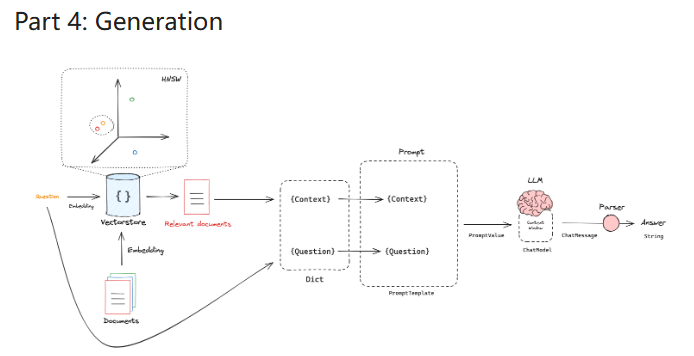